# Class 17: Boundary Value Problems 

Ch. 8, section 6: Boundary Value and Eigenvalue Problems 

- Complete the activities as instructed by the professor

#### Import any packages we need below (update as we go):

In [1]:
import numpy as np
import matplotlib.pyplot as plt

### Shooting Method

#### Book example 8.8 - Vertical position of a thrown ball

Let's solve the problem above with the thrown ball for the case where the ball lands back at $x=0$ after $t = 10$ seconds. 
$$\frac{d^2x}{dt^2} = -g $$

**First step**: break down second-order differential equation into two first-orders:


$$ \frac{dx}{dt} = y \qquad \frac{dy}{dt} = -g $$

**Solve** For the initial velocity using Runge-Kutta and Binary Search 

Binary Search Outline: 
1) Given an initial pair of points $x_1, x_2$ check that $f(x_1)$ and $f(x_2)$ have opposite signs. Also choose a target accuracy for the answer you want. 

2) Calculate the midpoint $x' = \frac{1}{2}(x_1+x_2)$ and evaluate $f(x')$

3) If $f(x')$ has the same sign as $f(x_1)$ then set $x_1 = x'$. Otherwise set $x_2 = x'$. 

4) If $|{x_1-x_2}|$ is greater than the target accuracy, repeat from step 2. Otherwise, calculate $\frac{1}{2}(x_1+x_2)$ once more and this is the final estimate of the position of the root. 


In [30]:
# 2nd Differential equation function
def f(r,t):
    x,v = r
    dx = v
    dv = -g
    return np.array([dx,dv], float)

#RK4 method
def height(v0, t_array):
    #t_array = linspace(t_i,t_f,N)
    #v0 = initial
    r = np.array([0,v0], float)
    #h = (t_f - t_i)/N
    h = (t_array[-1] - t_array[0])/len(t_array)
    for t in range(len(t_array)):
        k1 = h*f(r       , t_array[t]      )
        k2 = h*f(r + k1/2, t_array[t] + h/2)
        k3 = h*f(r + k2/2, t_array[t] + h/2)
        k4 = h*f(r + k3,   t_array[t] + h  )
        r += (k1 + 2*k2 + 2*k3 + k4)/6
    return r
        
#Constants/Knowns & time array
g = 9.8 # m/s^2
t_i = 0
t_f = 10.0
N = 1000
t_array = np.linspace(t_i,t_f,N)

#Binary search method
toll = 1e-10
v1 = 1
v2 = 1000
h1 = height(v1,t_array)[0]
h2 = height(v2,t_array)[0]
print(h1,h2)

while abs(h2-h1)>toll:
    vp = (v1+v2)/2
    hp = height(vp,t_array)[0]
    if h1*hp>0:
        v1 = vp
        h1 = hp
    else:
        v2 = vp
        h2 = hp
vel = (v1+v2)/2
print("Initial Velocity:", vel,"m/s")

-479.99999999999693 9510.000000000218
Initial Velocity: 49.000000000000696 m/s


**Check** Plug back in as initial condition using Runge-Kutta to double-check final position 

0.489509500000007


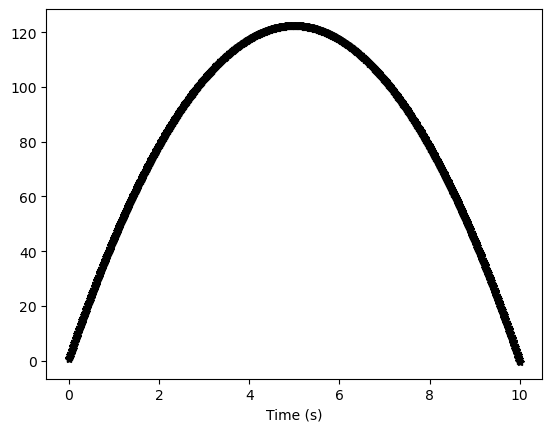

In [37]:
# 2nd Differential equation function
def f(r,t):
    x,v = r
    dx = v
    dv = -g
    return np.array([dx,dv], float)

#RK4 method



#Constants/Knowns & arrays
g = 9.81 # m/s^2
t_i = 0
t_f = 10.0
N = 1000
h = (t_f - t_i)/N
t_array = np.linspace(t_i,t_f,N)
x_array = np.zeros(N)
v_array = np.zeros(N)
r = np.array([0,vel], float)

for t in range(len(t_array)):
    k1 = h*f(r       , t_array[t]      )
    k2 = h*f(r + k1/2, t_array[t] + h/2)
    k3 = h*f(r + k2/2, t_array[t] + h/2)
    k4 = h*f(r + k3,   t_array[t] + h  )
    r += (k1 + 2*k2 + 2*k3 + k4)/6
    x_array[t] = r[0]
    v_array[t] = r[1]

plt.plot(t_array,x_array, "*k")
plt.xlabel("Time (s)")
print(x_array[0])

#### What if...

What if the final condition on position had been a value rather than 0? 

**answer**: Since searching for when the `h1` and `h2` values straddle a root, just subtract the final height from each of them to make it a zero

### Eigenvalue Problems

Calculate the ground state energy of an electron in a square potential well with infinitely high walls separated by a distance $L$ equal to the Bohr radius $a_0 = 5.292 \times 10^{-11}$ m.

$$ \frac{d\psi}{dx} = \phi \qquad \frac{d\phi}{dx} = \frac{2m}{\hbar^2}\left[ V(x) -E \right] \psi $$

**Secant method - solution to noninear equations**

new, hopefully better estimate of root is given by: 
$$x_3 = x_2 - f(x_2) \frac{x_1-x_2}{f(x_1)-f(x_2)}$$
where the new estimate is based on the previous two values in the series 

In [48]:
#potential
def V(x):
    return 0.0

#diff eq
def diff(chi,x,E):
    psi,phi = chi
    dpsi = phi
    dphi = (2*m/(hbar**2))*(V(x)-E)*psi
    return np.array([dpsi,dphi], float)

# constants
m = 9.1094e-31 # mass of an electron
hbar = 1.0546e-34 # planck's constnat over 2pi
e = 1.6022e-19 # electron charge
a0 = 5.2918e-11 # Bohr radius 
N = 1000
h = a0/N

#RK4 method
def RK4_wf(E):
    chi = np.array([0,1],float)
    x_array = np.linspace(0,a0,N)
    for x in x_array:
        k1 = h*diff(chi,x,E)
        k2 = h*diff(chi + k1/2, x + h/2, E)
        k3 = h*diff(chi + k2/2, x + h/2, E)
        k4 = h*diff(chi + k3,   x + h  , E)
        chi+= (k1 + 2*k2 + 2*k3 + k4)/6
    return chi[0]
        
#secant method for energy
E1 = 0.0
E2 = e
#initializing for loop which maps psi2->psi1, so psi2 must first be defined
psi2 = RK4_wf(E1)

toll = e*1e-3
while abs(E1-E2)>toll:
    psi1, psi2 = psi2, RK4_wf(E2)
    E1,E2 = E2, E2 - psi2 * (E1-E2)/(psi1-psi2)
    
    
print("E = ", E2/e, "eV")

E =  134.28637169369105 eV


### Exercise 8.14(a) - if time

Consider the one-dimensional, time-independent Schroedinger equation in a harmonic (i.e., quadratic) potential $V(x) = V_0x^2/a^2$, where $V_0$ and $a$ are constants.

**a)** Write down the Schroedinger equation for this problem and convert it from a second- order equation to two first-order ones, as in Example 8.9. Write a program, or modify the one from Example 8.9, to find the energies of the ground state and the first two excited states for these equations when $m$ is the electron mass, $V_0 = 50$ eV, and $a = 10^{−11}$ m. Note that in theory the wavefunction goes all the way out to $x = \pm \infty$, but you can get good answers by using a large but finite interval. Try using $x = −10a$ to $+10a$, with the wavefunction $\psi = 0$ at both boundaries. (In effect, you are putting the harmonic oscillator in a box with impenetrable walls.) The wavefunction is real everywhere, so you don’t need to use complex variables, and you can use evenly spaced points for the solution—there is no need to use an adaptive method for this problem.

The quantum harmonic oscillator is known to have energy states that are equally spaced. Check that this is true, to the precision of your calculation, for your answers. (Hint: The ground state has energy in the range 100 to 200 eV.)

In [ ]:



# constants
m = 9.1094e-31 # mass of an electron
hbar = 1.0546e-34 # planck's constnat over 2pi
e = 1.6022e-19 # electron charge
V0 = 50*e